# Data Augmentation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammadtalhaishtiaq/ai-orchestrator/blob/main/01-data-preprocessing/05_data_augmentation.ipynb)

**Time**: ~20 minutes

## What You'll Learn
- Why more data = better models
- Create synthetic data from existing data
- Image augmentation (flip, rotate, zoom)
- Tabular data augmentation (SMOTE)

## Why This Matters

Models need LOTS of data. But data is expensive!

**Example:** Self-driving car
```
Original images:  1,000 rain photos
After augmentation: 10,000 variations
  - Flipped
  - Rotated
  - Darker/Brighter
  - Zoomed
```

**Result:** Model learns better WITHOUT collecting more real data!

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE, ADASYN
from scipy import ndimage

np.random.seed(42)
print("Data Augmentation: Creating More Data from Less")

Data Augmentation: Creating More Data from Less


---
## 1. Why Augmentation?

In [2]:
# Small dataset problem
small_data = np.array([[1, 2], [2, 3], [3, 4], [4, 5], [5, 6]])
print("Small Dataset:")
print(small_data)
print(f"Only {len(small_data)} samples!")

print("\n❌ Problems with small data:")
print("  - Model can't learn patterns")
print("  - Overfits easily")
print("  - Poor generalization")

print("\n✅ Solution: Data Augmentation")
print("  - Create variations of existing data")
print("  - 10× more training examples")
print("  - Model sees more diversity")

Small Dataset:
[[1 2]
 [2 3]
 [3 4]
 [4 5]
 [5 6]]
Only 5 samples!

❌ Problems with small data:
  - Model can't learn patterns
  - Overfits easily
  - Poor generalization

✅ Solution: Data Augmentation
  - Create variations of existing data
  - 10× more training examples
  - Model sees more diversity


---
## 2. Image Augmentation (Simulated)

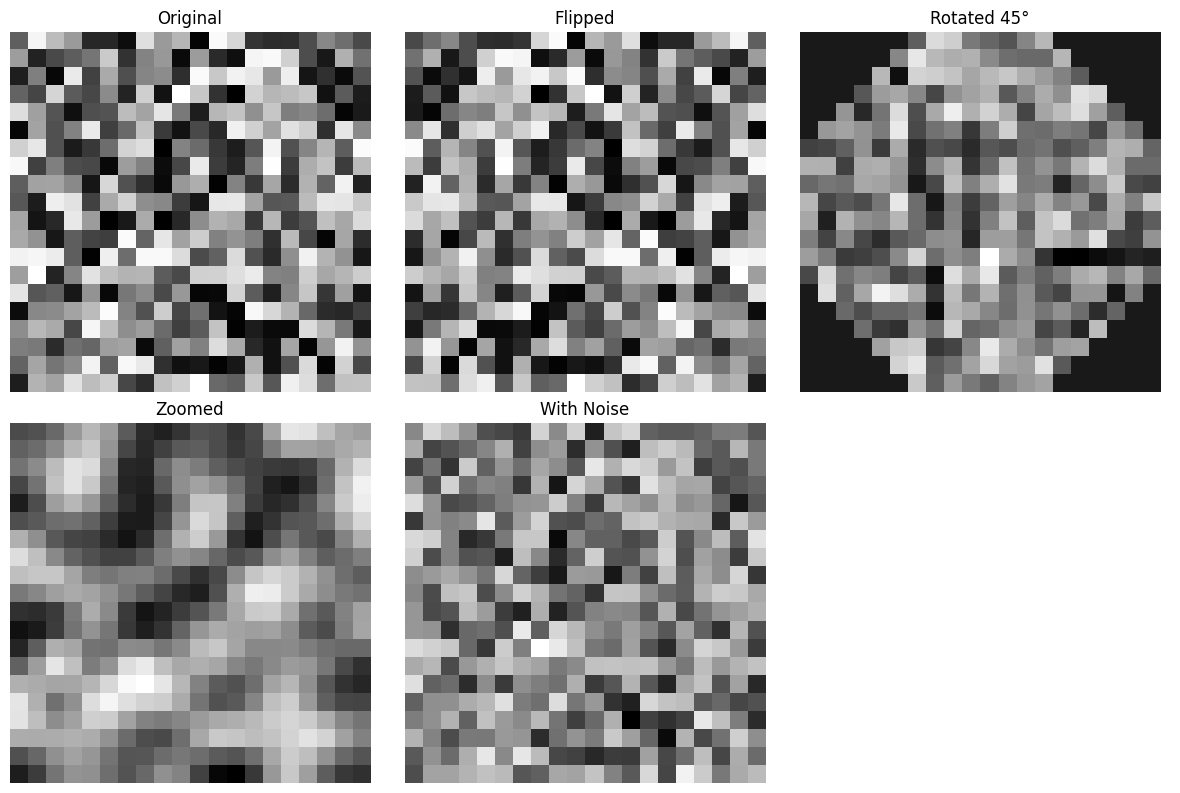

From 1 image → 5 variations!

✅ Image Augmentation:
  - Flip (horizontal/vertical)
  - Rotate (0-360°)
  - Zoom
  - Brightness/Contrast
  - Add noise


In [3]:
# Create a simple "image" (2D array)
np.random.seed(42)
original_image = np.random.rand(20, 20)

# Augmentation techniques
flipped = np.fliplr(original_image)                    # Horizontal flip
rotated = ndimage.rotate(original_image, 45, reshape=False)  # Rotate 45°
zoomed = ndimage.zoom(original_image[5:15, 5:15], 2)  # Zoom & crop
noisy = original_image + np.random.normal(0, 0.1, original_image.shape)  # Add noise

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

axes[0, 0].imshow(original_image, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(flipped, cmap='gray')
axes[0, 1].set_title('Flipped')
axes[0, 1].axis('off')

axes[0, 2].imshow(rotated, cmap='gray')
axes[0, 2].set_title('Rotated 45°')
axes[0, 2].axis('off')

axes[1, 0].imshow(zoomed, cmap='gray')
axes[1, 0].set_title('Zoomed')
axes[1, 0].axis('off')

axes[1, 1].imshow(noisy, cmap='gray')
axes[1, 1].set_title('With Noise')
axes[1, 1].axis('off')

axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("From 1 image → 5 variations!")
print("\n✅ Image Augmentation:")
print("  - Flip (horizontal/vertical)")
print("  - Rotate (0-360°)")
print("  - Zoom")
print("  - Brightness/Contrast")
print("  - Add noise")

---
## 3. Tabular Data: SMOTE

In [4]:
# Create imbalanced dataset
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    weights=[0.9, 0.1],  # 90% class 0, 10% class 1
    random_state=42
)

print("Imbalanced Dataset:")
print(f"Class 0: {(y == 0).sum()} samples")
print(f"Class 1: {(y == 1).sum()} samples")
print(f"\nImbalance ratio: {(y == 0).sum() / (y == 1).sum():.1f}:1")

print("\n❌ Problem: Model ignores minority class!")

Imbalanced Dataset:
Class 0: 895 samples
Class 1: 105 samples

Imbalance ratio: 8.5:1

❌ Problem: Model ignores minority class!


In [5]:
# SMOTE: Synthetic Minority Over-sampling Technique
# Creates synthetic samples between existing minority samples

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("After SMOTE:")
print(f"Class 0: {(y_resampled == 0).sum()} samples")
print(f"Class 1: {(y_resampled == 1).sum()} samples")
print(f"\nNow balanced! Created {(y_resampled == 1).sum() - (y == 1).sum()} synthetic samples")

print("\n✅ SMOTE creates NEW samples by:")
print("  1. Finding minority samples")
print("  2. For each, find K nearest neighbors")
print("  3. Create synthetic sample BETWEEN them")
print("\n  Example: Point A=(1,2), Point B=(3,4)")
print("  Synthetic: (2, 3)  ← Midpoint!")

After SMOTE:
Class 0: 895 samples
Class 1: 895 samples

Now balanced! Created 790 synthetic samples

✅ SMOTE creates NEW samples by:
  1. Finding minority samples
  2. For each, find K nearest neighbors
  3. Create synthetic sample BETWEEN them

  Example: Point A=(1,2), Point B=(3,4)
  Synthetic: (2, 3)  ← Midpoint!


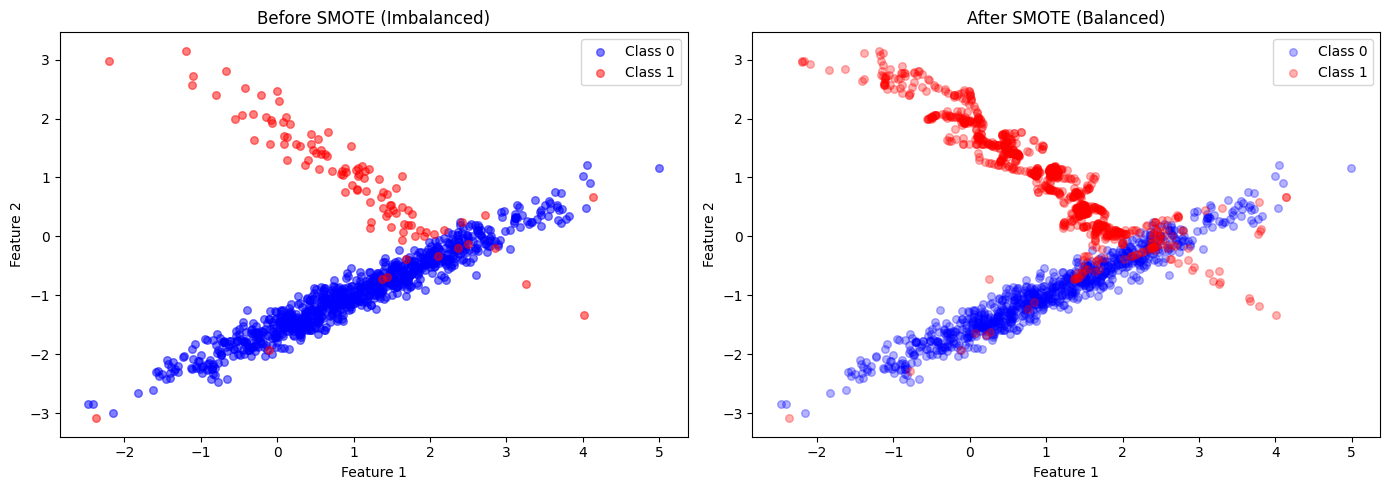

Notice: New red points fill the space!


In [6]:
# Visualize SMOTE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before SMOTE
axes[0].scatter(X[y==0, 0], X[y==0, 1], alpha=0.5, s=30, label='Class 0', color='blue')
axes[0].scatter(X[y==1, 0], X[y==1, 1], alpha=0.5, s=30, label='Class 1', color='red')
axes[0].set_title('Before SMOTE (Imbalanced)')
axes[0].legend()
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# After SMOTE
axes[1].scatter(X_resampled[y_resampled==0, 0], X_resampled[y_resampled==0, 1], 
                alpha=0.3, s=30, label='Class 0', color='blue')
axes[1].scatter(X_resampled[y_resampled==1, 0], X_resampled[y_resampled==1, 1], 
                alpha=0.3, s=30, label='Class 1', color='red')
axes[1].set_title('After SMOTE (Balanced)')
axes[1].legend()
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

print("Notice: New red points fill the space!")

---
## 4. ADASYN (Adaptive SMOTE)

In [7]:
# ADASYN: Focuses on hard-to-learn samples
# Creates MORE synthetic samples in difficult regions

adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X, y)

print("After ADASYN:")
print(f"Class 0: {(y_adasyn == 0).sum()} samples")
print(f"Class 1: {(y_adasyn == 1).sum()} samples")

print("\n✅ ADASYN vs SMOTE:")
print("  - SMOTE: Uniform sampling")
print("  - ADASYN: More samples in hard regions")
print("  - ADASYN: Better for complex boundaries")

After ADASYN:
Class 0: 895 samples
Class 1: 895 samples

✅ ADASYN vs SMOTE:
  - SMOTE: Uniform sampling
  - ADASYN: More samples in hard regions
  - ADASYN: Better for complex boundaries


---
## 5. Random Noise Injection

In [8]:
# Simple augmentation: Add small noise
original_data = np.array([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])

def augment_with_noise(data, num_augmented=3, noise_level=0.1):
    """Add noise to create augmented samples"""
    augmented = []
    for sample in data:
        for _ in range(num_augmented):
            noise = np.random.normal(0, noise_level, sample.shape)
            augmented.append(sample + noise)
    return np.array(augmented)

augmented_data = augment_with_noise(original_data, num_augmented=3, noise_level=0.2)

print("Original (3 samples):")
print(original_data)

print(f"\nAugmented ({len(augmented_data)} samples):")
print(augmented_data)

print(f"\n✅ From {len(original_data)} → {len(augmented_data)} samples!")
print("   (3× augmentation per sample)")

Original (3 samples):
[[1. 2.]
 [3. 4.]
 [5. 6.]]

Augmented (9 samples):
[[0.99247306 2.22066038]
 [1.02284553 2.03006035]
 [0.92727756 1.98861088]
 [3.06156035 3.65796632]
 [2.73036292 4.14865282]
 [3.03417309 3.96320333]
 [5.00368679 6.06951634]
 [4.89204806 5.84433905]
 [5.03916905 5.80432544]]

✅ From 3 → 9 samples!
   (3× augmentation per sample)


---
## 6. Impact on Model Performance

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model 1: Without augmentation
model_no_aug = LogisticRegression(random_state=42, max_iter=1000)
model_no_aug.fit(X_train, y_train)
score_no_aug = model_no_aug.score(X_test, y_test)

print("Without Augmentation:")
print(f"  Accuracy: {score_no_aug:.1%}")

# Model 2: With SMOTE
X_train_smote, y_train_smote = SMOTE(random_state=42).fit_resample(X_train, y_train)
model_with_aug = LogisticRegression(random_state=42, max_iter=1000)
model_with_aug.fit(X_train_smote, y_train_smote)
score_with_aug = model_with_aug.score(X_test, y_test)

print("\nWith SMOTE Augmentation:")
print(f"  Accuracy: {score_with_aug:.1%}")

print(f"\n✅ Improvement: {(score_with_aug - score_no_aug):.1%}")

Without Augmentation:
  Accuracy: 97.0%

With SMOTE Augmentation:
  Accuracy: 98.3%

✅ Improvement: 1.3%


---
## 7. Augmentation Strategies by Data Type

### Images
```python
# Using Keras ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,       # Rotate ±20°
    width_shift_range=0.2,   # Shift left/right
    height_shift_range=0.2,  # Shift up/down
    horizontal_flip=True,    # Flip horizontally
    zoom_range=0.2           # Zoom in/out
)
```

### Text
```python
# Synonym replacement
"The movie was great" → "The film was excellent"

# Back translation
English → French → English
"I love dogs" → "J'aime les chiens" → "I like dogs"
```

### Audio
```python
# Speed up/down
# Add background noise
# Change pitch
# Time stretching
```

---
## 8. When to Use Augmentation

✅ **USE when:**
- Small dataset (<10,000 samples)
- Imbalanced classes
- Overfitting (high train, low test accuracy)
- Deep learning (needs lots of data)

❌ **DON'T USE when:**
- Already have millions of samples
- Augmentation changes label (rotate upside-down text)
- Testing critical systems (medical)
- Tree-based models on tabular data

---
## Comparison Table

| Technique | Data Type | When to Use | Pros | Cons |
|-----------|-----------|-------------|------|------|
| Flip/Rotate | Images | Always safe | Simple, fast | Limited diversity |
| Crop/Zoom | Images | Object detection | Simulates scale | May lose context |
| Color Jitter | Images | Color matters | Robust to lighting | Can be unrealistic |
| SMOTE | Tabular | Imbalanced | Balances classes | May create noise |
| ADASYN | Tabular | Hard boundaries | Focuses on difficult | Slower than SMOTE |
| Noise Injection | Any | Regularization | Prevents overfitting | Too much = bad |
| Mixup | Images | Deep learning | Smooth boundaries | Complex |
| Back Translation | Text | NLP | Natural variations | Needs translation API |

---
## Key Takeaways

1. **Augmentation creates more data** from existing data
2. **Images**: Flip, rotate, zoom, adjust colors
3. **Tabular**: SMOTE for imbalanced classes
4. **Always augment AFTER train-test split**
5. **Don't augment test set** (measure on real data)
6. **Augmentation ≠ real data** (use wisely)
7. **Check if augmented samples make sense**

**Most common**: SMOTE for imbalanced tabular data, Keras ImageDataGenerator for images

---
## Your Turn

1. Load an imbalanced dataset
2. Check class distribution
3. Apply SMOTE or ADASYN
4. Train model before/after augmentation
5. Compare results

In [10]:
# Your code here